In [64]:
!pip install pyspark

## Solución 2

In [65]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(10,6)

In [66]:
spark = SparkSession.builder.appName('Edad Hurto').getOrCreate()

cargar DATASET

In [67]:
df = spark.read.csv('hurto_transporte_publico.csv', header=True, inferSchema=True)


ver el dataSet

In [68]:
df.show(5)

+-------------------+--------+----------+------------+------+----+--------------------+-----------+-------------------+----------+---------+------------+--------------+----------------+---------------+--------+---------------+---------+---------------+-----------------+-------------+--------------+---------------+--------------------+-------------+-------------+-----------+--------------+-------------------+--------------------+----------+------+--------+--------+-------------+
|        fecha_hecho|cantidad|   latitud|    longitud|  sexo|edad|        estado_civil|grupo_actor|actividad_delictiva|parentesco|ocupacion|discapacidad|grupo_especial|medio_transporte|nivel_academico| testigo|       conducta|modalidad|caracterizacion|conducta_especial|   arma_medio|articulo_penal|categoria_penal|       nombre_barrio|codigo_barrio|codigo_comuna|      lugar|sede_receptora|               bien|      categoria_bien|grupo_bien|modelo|   color| permiso|unidad_medida|
+-------------------+--------+----

In [69]:
df.printSchema()

root
 |-- fecha_hecho: timestamp (nullable = true)
 |-- cantidad: double (nullable = true)
 |-- latitud: double (nullable = true)
 |-- longitud: double (nullable = true)
 |-- sexo: string (nullable = true)
 |-- edad: integer (nullable = true)
 |-- estado_civil: string (nullable = true)
 |-- grupo_actor: string (nullable = true)
 |-- actividad_delictiva: string (nullable = true)
 |-- parentesco: string (nullable = true)
 |-- ocupacion: string (nullable = true)
 |-- discapacidad: string (nullable = true)
 |-- grupo_especial: string (nullable = true)
 |-- medio_transporte: string (nullable = true)
 |-- nivel_academico: string (nullable = true)
 |-- testigo: string (nullable = true)
 |-- conducta: string (nullable = true)
 |-- modalidad: string (nullable = true)
 |-- caracterizacion: string (nullable = true)
 |-- conducta_especial: string (nullable = true)
 |-- arma_medio: string (nullable = true)
 |-- articulo_penal: string (nullable = true)
 |-- categoria_penal: string (nullable = true)


In [70]:
# cantidad de filas
df.count()

27022

LIMPIEZA

In [83]:
# para ver el nombre de las columnas
df = df.replace("Sin dato",None)

In [72]:
df.show(5)

+-------------------+--------+----------+------------+------+----+--------------------+-----------+-------------------+----------+---------+------------+--------------+----------------+---------------+-------+---------------+---------+---------------+-----------------+-------------+--------------+---------------+--------------------+-------------+-------------+-----------+--------------+-------------------+--------------------+----------+------+------+-------+-------------+
|        fecha_hecho|cantidad|   latitud|    longitud|  sexo|edad|        estado_civil|grupo_actor|actividad_delictiva|parentesco|ocupacion|discapacidad|grupo_especial|medio_transporte|nivel_academico|testigo|       conducta|modalidad|caracterizacion|conducta_especial|   arma_medio|articulo_penal|categoria_penal|       nombre_barrio|codigo_barrio|codigo_comuna|      lugar|sede_receptora|               bien|      categoria_bien|grupo_bien|modelo| color|permiso|unidad_medida|
+-------------------+--------+----------+-

operaciones sobre columnas

In [73]:
from pyarrow import timestamp
df = df.withColumn("fecha_hecho", to_timestamp(col("fecha_hecho")))
df.show()

+-------------------+--------+----------+------------+------+----+--------------------+-----------+-------------------+----------+---------+------------+--------------+----------------+---------------+-------+---------------+----------+---------------+-----------------+-------------+--------------+---------------+--------------------+-------------+-------------+--------------------+--------------+--------------------+--------------------+----------+------+------+-------+-------------+
|        fecha_hecho|cantidad|   latitud|    longitud|  sexo|edad|        estado_civil|grupo_actor|actividad_delictiva|parentesco|ocupacion|discapacidad|grupo_especial|medio_transporte|nivel_academico|testigo|       conducta| modalidad|caracterizacion|conducta_especial|   arma_medio|articulo_penal|categoria_penal|       nombre_barrio|codigo_barrio|codigo_comuna|               lugar|sede_receptora|                bien|      categoria_bien|grupo_bien|modelo| color|permiso|unidad_medida|
+-------------------

In [74]:
df = df.withColumn("anio",year(col("fecha_hecho"))) \
.withColumn("mes",month(col("fecha_hecho"))) \
.withColumn("dia",dayofmonth(col("fecha_hecho"))) \
.withColumn("hora",hour(col("fecha_hecho"))) \
.withColumn("dia_semana",date_format("fecha_hecho","EEE"))

In [75]:
df.show(5)

+-------------------+--------+----------+------------+------+----+--------------------+-----------+-------------------+----------+---------+------------+--------------+----------------+---------------+-------+---------------+---------+---------------+-----------------+-------------+--------------+---------------+--------------------+-------------+-------------+-----------+--------------+-------------------+--------------------+----------+------+------+-------+-------------+----+---+---+----+----------+
|        fecha_hecho|cantidad|   latitud|    longitud|  sexo|edad|        estado_civil|grupo_actor|actividad_delictiva|parentesco|ocupacion|discapacidad|grupo_especial|medio_transporte|nivel_academico|testigo|       conducta|modalidad|caracterizacion|conducta_especial|   arma_medio|articulo_penal|categoria_penal|       nombre_barrio|codigo_barrio|codigo_comuna|      lugar|sede_receptora|               bien|      categoria_bien|grupo_bien|modelo| color|permiso|unidad_medida|anio|mes|dia|h

In [76]:
df.count()

27022

In [77]:
df.filter((col("edad")>=  0)  & ((col("edad"))<=100))

DataFrame[fecha_hecho: timestamp, cantidad: double, latitud: double, longitud: double, sexo: string, edad: int, estado_civil: string, grupo_actor: string, actividad_delictiva: string, parentesco: string, ocupacion: string, discapacidad: string, grupo_especial: string, medio_transporte: string, nivel_academico: string, testigo: string, conducta: string, modalidad: string, caracterizacion: string, conducta_especial: string, arma_medio: string, articulo_penal: string, categoria_penal: string, nombre_barrio: string, codigo_barrio: string, codigo_comuna: string, lugar: string, sede_receptora: string, bien: string, categoria_bien: string, grupo_bien: string, modelo: int, color: string, permiso: string, unidad_medida: string, anio: int, mes: int, dia: int, hora: int, dia_semana: string]

In [78]:
df.count()

27022

In [79]:
df = df.filter(col("latitud").between(-90,90) &
               col("latitud").between(-180,180))

In [80]:
df.count()

24594

CREACIÓN DE DATAFRAME

In [81]:
genero = df.groupBy("sexo").count()
genero.show()

+------+-----+
|  sexo|count|
+------+-----+
|  NULL|   31|
|Hombre|12374|
| Mujer|12189|
+------+-----+



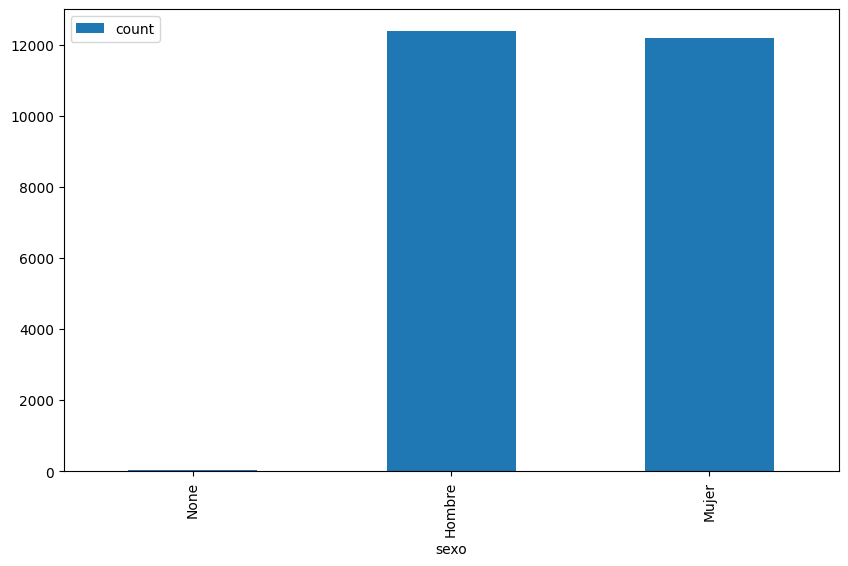

In [82]:
genero_pd = genero.toPandas()
genero_pd.plot(x="sexo", y="count", kind="bar")
plt.show()


In [84]:
df.groupBy("sexo","modalidad").count().show()

+------+--------------------+-----+
|  sexo|           modalidad|count|
+------+--------------------+-----+
| Mujer|      Miedo o terror|    2|
| Mujer|              Atraco| 3497|
|Hombre|  Comisión de delito|   41|
|Hombre| Simulando necesidad|    4|
|  NULL|                NULL|    6|
|  NULL|        Escopolamina|    2|
| Mujer|              Halado|    2|
| Mujer|        Escopolamina|   97|
|Hombre|Rompimiento cerra...|   26|
|  NULL|              Atraco|   23|
|Hombre|        Escopolamina|  279|
| Mujer|Rompimiento de ve...|    1|
|Hombre|            Raponazo|  401|
| Mujer|              Engaño|   86|
| Mujer|          Cosquilleo| 6838|
|Hombre|              Atraco| 4727|
|Hombre|            Descuido| 1158|
|Hombre|                NULL|   28|
|Hombre|              Halado|    8|
| Mujer| Simulando necesidad|    4|
+------+--------------------+-----+
only showing top 20 rows


In [85]:
df.groupBy("sexo","modalidad").count().orderBy(desc("count")).show()

+------+--------------------+-----+
|  sexo|           modalidad|count|
+------+--------------------+-----+
| Mujer|          Cosquilleo| 6838|
|Hombre|          Cosquilleo| 5617|
|Hombre|              Atraco| 4727|
| Mujer|              Atraco| 3497|
|Hombre|            Descuido| 1158|
| Mujer|            Descuido|  944|
| Mujer|            Raponazo|  616|
|Hombre|            Raponazo|  401|
|Hombre|        Escopolamina|  279|
| Mujer|        Escopolamina|   97|
| Mujer|              Engaño|   86|
|Hombre|              Engaño|   69|
|Hombre|  Comisión de delito|   41|
| Mujer|              Fleteo|   32|
| Mujer|  Comisión de delito|   31|
|Hombre|                NULL|   28|
|Hombre|Rompimiento cerra...|   26|
|  NULL|              Atraco|   23|
| Mujer|                NULL|   18|
| Mujer|Rompimiento cerra...|   12|
+------+--------------------+-----+
only showing top 20 rows


In [86]:
hora_df = df.groupBy("hora").count().orderBy(desc("count"))
hora_df.show()

+----+-----+
|hora|count|
+----+-----+
|  12| 2600|
|  23| 2374|
|  11| 2206|
|  22| 1522|
|  13| 1510|
|   0| 1385|
|  21| 1045|
|  10| 1039|
|  20|  966|
|  14|  936|
|  15|  843|
|   1|  829|
|  19|  789|
|  16|  740|
|  17|  725|
|   7|  687|
|   8|  685|
|  18|  660|
|   9|  587|
|   2|  572|
+----+-----+
only showing top 20 rows


In [87]:
dia_df = df.groupBy("dia_semana").count().orderBy(desc("count"))
dia_df.show()

+----------+-----+
|dia_semana|count|
+----------+-----+
|       Fri| 4148|
|       Wed| 4109|
|       Thu| 3992|
|       Tue| 3911|
|       Sat| 3468|
|       Mon| 3203|
|       Sun| 1763|
+----------+-----+

